# Mortality Simulation Demonstration

This notebook demonstrates the mortality simulation package, comparing single life vs joint life models with different parameter configurations.

## Contents
1. Setup and Data Generation
2. Single Life Baseline Simulation
3. Joint Life Simulations with Different Configurations
4. Results Comparison and Visualization

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../')  # noqa: E402
from mortality_simulations import (
    stochastic_runs_hybrid,
    stochastic_runs_portfolio,
    get_joint_life_params,
    list_param_configs,
)

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Setup and Data Generation

We create a sample portfolio with:
- 10,000 total lives
- 20% on joint life policies (1,000 policies × 2 lives = 2,000 lives)
- 80% single life policies (8,000 lives)

**Important**: We fix the random seed and freeze qx values to ensure comparability across scenarios.

In [4]:
# Configuration
TOTAL_LIVES = 10_000
JOINT_LIFE_FRACTION = 0.20
N_TRIALS = 1_000
RANDOM_SEED = 42

# Calculate split
n_joint_lives = int(TOTAL_LIVES * JOINT_LIFE_FRACTION)
n_joint_policies = n_joint_lives // 2  # 2 lives per joint policy
n_single_lives = TOTAL_LIVES - n_joint_lives

print(f"Portfolio composition:")
print(f"  Single lives: {n_single_lives:,}")
print(f"  Joint life policies: {n_joint_policies:,} ({n_joint_lives:,} lives)")
print(f"  Total lives: {TOTAL_LIVES:,}")

Portfolio composition:
  Single lives: 8,000
  Joint life policies: 1,000 (2,000 lives)
  Total lives: 10,000


In [5]:
def generate_portfolio(n_single: int, n_joint_policies: int, seed: int = 42) -> pd.DataFrame:
    """
    Generate a mixed portfolio with fixed characteristics.
    
    Returns DataFrame with columns:
    - policy_number, life_id, life_status
    - volume, baseline_qx, shocked_qx
    """
    np.random.seed(seed)
    data = []
    
    # Generate single life policies
    for i in range(n_single):
        data.append({
            'policy_number': f'SINGLE_{i:05d}',
            'life_id': 'A',
            'life_status': 'single',
            'volume': np.random.lognormal(mean=13, sigma=1.5),  # ~500K median
            'baseline_qx': np.random.beta(2, 80),  # ~2.5% mean
            'shocked_qx': None,  # Will be set below
        })
    
    # Generate joint life policies (2 lives per policy)
    for i in range(n_joint_policies):
        policy_num = f'JOINT_{i:05d}'
        volume = np.random.lognormal(mean=14, sigma=1.2)  # Higher for joint
        
        # Life A
        qx_a = np.random.beta(2, 80)
        data.append({
            'policy_number': policy_num,
            'life_id': 'A',
            'life_status': 'joint',
            'volume': volume,
            'baseline_qx': qx_a,
            'shocked_qx': None,
        })
        
        # Life B (slightly different qx)
        qx_b = np.random.beta(2, 80)
        data.append({
            'policy_number': policy_num,
            'life_id': 'B',
            'life_status': 'joint',
            'volume': volume,
            'baseline_qx': qx_b,
            'shocked_qx': None,
        })
    
    df = pd.DataFrame(data)
    
    # Set shocked qx as 1.5x baseline (fixed multiplier for comparability)
    df['shocked_qx'] = np.minimum(df['baseline_qx'] * 1.5, 1.0)
    
    return df

# Generate the portfolio
portfolio = generate_portfolio(n_single_lives, n_joint_policies, seed=RANDOM_SEED)

print(f"\nPortfolio generated:")
print(portfolio.groupby('life_status').agg({
    'policy_number': 'nunique',
    'volume': ['mean', 'sum'],
    'baseline_qx': 'mean'
}).round(4))


Portfolio generated:
            policy_number        volume               baseline_qx
                  nunique          mean           sum        mean
life_status                                                      
joint                1000  2.341959e+06  4.683918e+09      0.0246
single               8000  1.408524e+06  1.126819e+10      0.0243


In [6]:
# Display sample of data
print("Sample of single life policies:")
display(portfolio[portfolio['life_status'] == 'single'].head())

print("\nSample of joint life policies:")
display(portfolio[portfolio['life_status'] == 'joint'].head(6))

Sample of single life policies:


,policy_number,life_id,life_status,volume,baseline_qx,shocked_qx
0,SINGLE_00000,A,single,931984.282744,0.020860,0.031290
1,SINGLE_00001,A,single,713796.564486,0.050892,0.076338
2,SINGLE_00002,A,single,218772.667366,0.032015,0.048023
3,SINGLE_00003,A,single,110622.163730,0.003789,0.005684
4,SINGLE_00004,A,single,113319.199145,0.005729,0.008594



Sample of joint life policies:


,policy_number,life_id,life_status,volume,baseline_qx,shocked_qx
8000,JOINT_00000,A,joint,1.560417e+05,0.040125,0.060187
8001,JOINT_00000,B,joint,1.560417e+05,0.023416,0.035124
8002,JOINT_00001,A,joint,3.286238e+05,0.021541,0.032311
8003,JOINT_00001,B,joint,3.286238e+05,0.031728,0.047592
8004,JOINT_00002,A,joint,2.315287e+06,0.030170,0.045255
8005,JOINT_00002,B,joint,2.315287e+06,0.031286,0.046929


## 2. Single Life Baseline Simulation

First, we run the entire portfolio through the **single life simulation** as a baseline. This treats all lives as independent - ignoring the joint life structure.

In [7]:
# Run single life simulation on entire portfolio
np.random.seed(RANDOM_SEED)

baseline_results = stochastic_runs_hybrid(
    data=portfolio,
    n_trials=N_TRIALS,
    volume_col='volume',
    baseline_qx_col='baseline_qx',
    shocked_qx_col='shocked_qx',
    n_processes=1,  # Single process for reproducibility
)

print("Single Life Baseline Results:")
print(f"  Mean claim count: {np.mean(baseline_results['claim_count_baseline']):.1f}")
print(f"  Mean claim volume: ${np.mean(baseline_results['claim_volume_baseline']):,.0f}")
print(f"  Std claim volume: ${np.std(baseline_results['claim_volume_baseline']):,.0f}")

Single Life Baseline Results:
  Mean claim count: 244.4
  Mean claim volume: $387,530,372
  Std claim volume: $61,167,310


## 3. Joint Life Simulations with Different Configurations

Now we run the portfolio using the joint life model with different parameter configurations.

**Key difference**: Joint life policies use "last-to-die" logic - claims only trigger when BOTH lives have died.

In [8]:
# Show available configurations
print("Available parameter configurations:\n")
for name, desc in list_param_configs().items():
    params = get_joint_life_params(name)
    print(f"{name}:")
    print(f"  rho={params['rho']}, contagion={params['contagion_multiplier']}")
    print(f"  {desc}\n")

Available parameter configurations:

correlation_only:
  rho=0.25, contagion=1.0
  Uses correlation (rho) only to model joint death dependency. Simpler single-parameter approach. Recommended for single-period models.

contagion_only:
  rho=0.0, contagion=1.5
  Uses contagion multiplier only (independent base mortality). Models pure widow/widower effect without shared environment correlation.

low_correlation_with_contagion:
  rho=0.05, contagion=1.35
  Low correlation for shared environment, plus time-weighted contagion. Separates the two effects while avoiding double-counting. Contagion of 1.35 reflects annual average of decaying widow effect.

moderate_combined:
  rho=0.1, contagion=1.25
  Moderate values of both parameters. Use when you have evidence for both shared environment and causal contagion.

multi_period_literature:
  rho=0.05, contagion=1.5
  Based on actuarial literature for multi-period projections. Low rho for shared environment, standard contagion for widow effect. In 

In [9]:
# Run simulations with different configurations
configs_to_test = [
    'correlation_only',
    'contagion_only', 
    'low_correlation_with_contagion',
    'moderate_combined',
]

joint_results = {}

for config_name in configs_to_test:
    params = get_joint_life_params(config_name)
    
    # Reset random seed for each run to ensure same random draws
    np.random.seed(RANDOM_SEED)
    
    results = stochastic_runs_portfolio(
        data=portfolio,
        n_trials=N_TRIALS,
        volume_col='volume',
        baseline_qx_col='baseline_qx',
        shocked_qx_col='shocked_qx',
        life_status_col='life_status',
        policy_col='policy_number',
        life_id_col='life_id',
        rho=params['rho'],
        contagion_multiplier=params['contagion_multiplier'],
        n_processes=1,
    )
    
    joint_results[config_name] = results
    
    print(f"\n{config_name} (rho={params['rho']}, contagion={params['contagion_multiplier']}):")
    print(f"  Total mean claim volume: ${np.mean(results['claim_volume_baseline']):,.0f}")
    print(f"  - Single life portion: ${np.mean(results['single_life_claim_volume_baseline']):,.0f}")
    print(f"  - Joint life portion: ${np.mean(results['joint_life_claim_volume_baseline']):,.0f}")


correlation_only (rho=0.25, contagion=1.0):
  Total mean claim volume: $276,064,852
  - Single life portion: $271,936,551
  - Joint life portion: $4,128,301

contagion_only (rho=0.0, contagion=1.5):
  Total mean claim volume: $274,717,506
  - Single life portion: $271,936,551
  - Joint life portion: $2,780,955

low_correlation_with_contagion (rho=0.05, contagion=1.35):
  Total mean claim volume: $274,916,540
  - Single life portion: $271,936,551
  - Joint life portion: $2,979,989

moderate_combined (rho=0.1, contagion=1.25):
  Total mean claim volume: $275,172,199
  - Single life portion: $271,936,551
  - Joint life portion: $3,235,647


## 4. Results Comparison and Visualization

In [10]:
# Create summary comparison table
summary_data = []

# Add baseline
summary_data.append({
    'Configuration': 'Single Life (Baseline)',
    'rho': '-',
    'contagion': '-',
    'Mean Claims': np.mean(baseline_results['claim_count_baseline']),
    'Mean Volume': np.mean(baseline_results['claim_volume_baseline']),
    'Std Volume': np.std(baseline_results['claim_volume_baseline']),
    'P95 Volume': np.percentile(baseline_results['claim_volume_baseline'], 95),
    'P99 Volume': np.percentile(baseline_results['claim_volume_baseline'], 99),
})

# Add joint life configurations
for config_name in configs_to_test:
    params = get_joint_life_params(config_name)
    results = joint_results[config_name]
    
    summary_data.append({
        'Configuration': config_name,
        'rho': params['rho'],
        'contagion': params['contagion_multiplier'],
        'Mean Claims': np.mean(results['claim_count_baseline']),
        'Mean Volume': np.mean(results['claim_volume_baseline']),
        'Std Volume': np.std(results['claim_volume_baseline']),
        'P95 Volume': np.percentile(results['claim_volume_baseline'], 95),
        'P99 Volume': np.percentile(results['claim_volume_baseline'], 99),
    })

summary_df = pd.DataFrame(summary_data)

# Format for display
summary_display = summary_df.copy()
for col in ['Mean Volume', 'Std Volume', 'P95 Volume', 'P99 Volume']:
    summary_display[col] = summary_display[col].apply(lambda x: f'${x:,.0f}')
summary_display['Mean Claims'] = summary_display['Mean Claims'].apply(lambda x: f'{x:.1f}')

print("Comparison Summary:")
display(summary_display)

Comparison Summary:


,Configuration,rho,contagion,Mean Claims,Mean Volume,Std Volume,P95 Volume,P99 Volume
0,Single Life (Baseline),-,-,244.4,"$387,530,372","$61,167,310","$499,343,039","$560,675,249"
1,correlation_only,0.25,1.0,196.3,"$276,064,852","$51,700,527","$364,014,383","$420,759,437"
2,contagion_only,0.0,1.5,195.8,"$274,717,506","$51,660,897","$363,862,899","$420,731,548"
3,low_correlation_with_contagion,0.05,1.35,195.8,"$274,916,540","$51,649,814","$363,862,899","$420,731,548"
4,moderate_combined,0.1,1.25,196.0,"$275,172,199","$51,642,335","$363,862,899","$419,856,308"


### 4.1 Histogram of Total Loss Costs

Comparing the distribution of total claim volumes across different configurations.

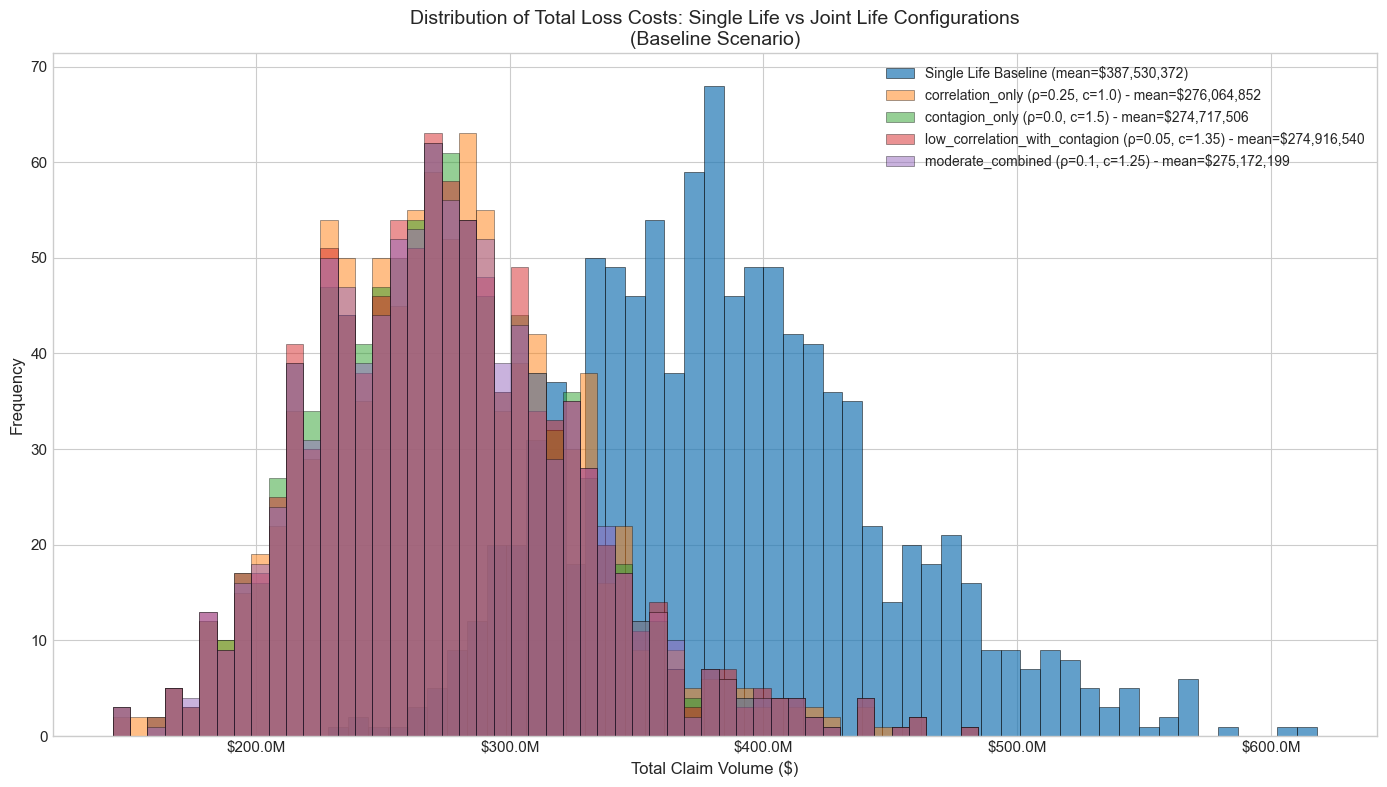

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))

# Colors for different configurations
colors = plt.cm.tab10.colors

# Plot baseline
ax.hist(
    baseline_results['claim_volume_baseline'],
    bins=50,
    alpha=0.7,
    label=f'Single Life Baseline (mean=${np.mean(baseline_results["claim_volume_baseline"]):,.0f})',
    color=colors[0],
    edgecolor='black',
    linewidth=0.5,
)

# Plot joint life configurations
for i, config_name in enumerate(configs_to_test):
    results = joint_results[config_name]
    params = get_joint_life_params(config_name)
    
    ax.hist(
        results['claim_volume_baseline'],
        bins=50,
        alpha=0.5,
        label=f'{config_name} (ρ={params["rho"]}, c={params["contagion_multiplier"]}) - mean=${np.mean(results["claim_volume_baseline"]):,.0f}',
        color=colors[i + 1],
        edgecolor='black',
        linewidth=0.5,
    )

ax.set_xlabel('Total Claim Volume ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Total Loss Costs: Single Life vs Joint Life Configurations\n(Baseline Scenario)', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

### 4.2 Box Plot Comparison

/var/folders/jr/gvp86vs51hv145cl97rcnsph0000gn/T/ipykernel_94661/738192494.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)


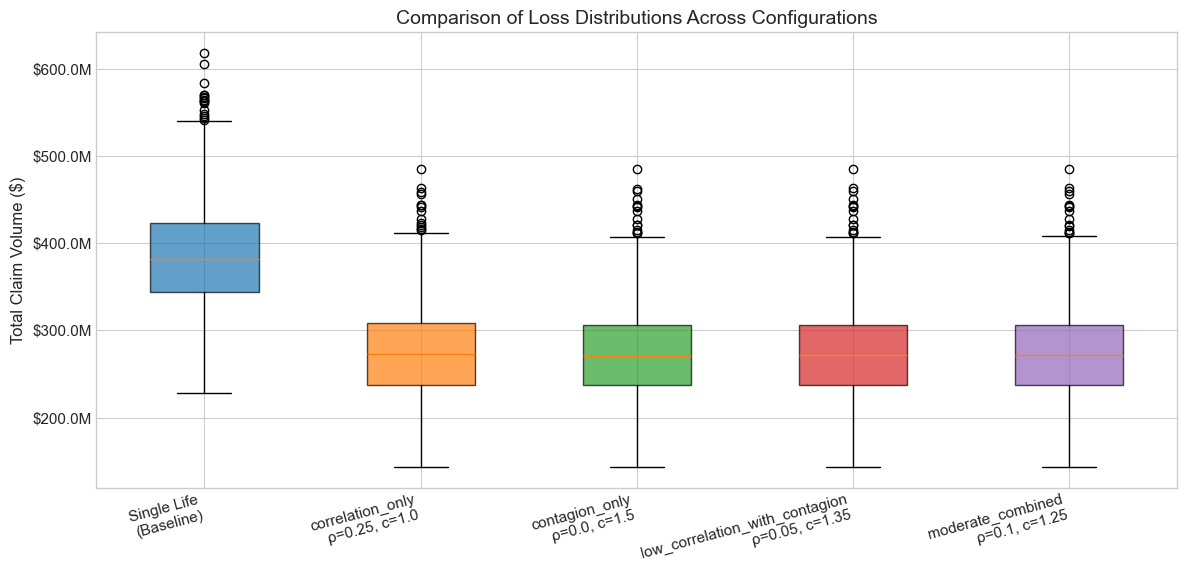

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for box plot
box_data = [baseline_results['claim_volume_baseline']]
box_labels = ['Single Life\n(Baseline)']

for config_name in configs_to_test:
    results = joint_results[config_name]
    params = get_joint_life_params(config_name)
    box_data.append(results['claim_volume_baseline'])
    box_labels.append(f'{config_name}\nρ={params["rho"]}, c={params["contagion_multiplier"]}')

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)

# Color the boxes
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i])
    patch.set_alpha(0.7)

ax.set_ylabel('Total Claim Volume ($)', fontsize=12)
ax.set_title('Comparison of Loss Distributions Across Configurations', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Reduction in Claims Due to Joint Life Treatment

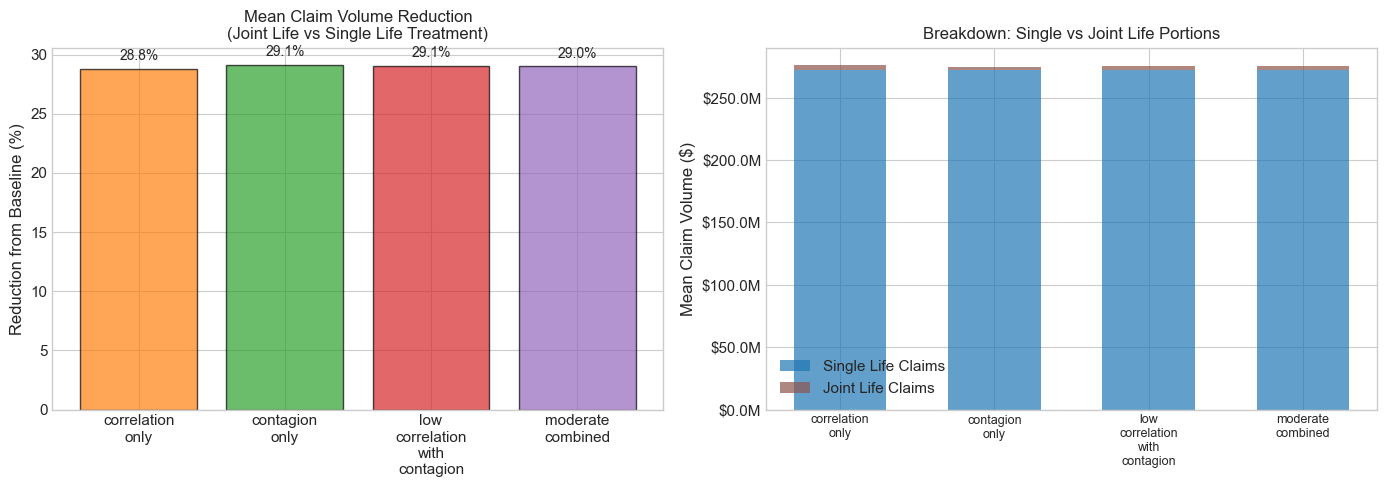

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Calculate reduction percentages
baseline_mean = np.mean(baseline_results['claim_volume_baseline'])
reductions = []
labels = []

for config_name in configs_to_test:
    results = joint_results[config_name]
    joint_mean = np.mean(results['claim_volume_baseline'])
    reduction_pct = (baseline_mean - joint_mean) / baseline_mean * 100
    reductions.append(reduction_pct)
    labels.append(config_name.replace('_', '\n'))

# Bar chart of reductions
bars = ax1.bar(labels, reductions, color=colors[1:len(configs_to_test)+1], alpha=0.7, edgecolor='black')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_ylabel('Reduction from Baseline (%)', fontsize=12)
ax1.set_title('Mean Claim Volume Reduction\n(Joint Life vs Single Life Treatment)', fontsize=12)

# Add value labels on bars
for bar, val in zip(bars, reductions):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# Joint life portion breakdown
single_portions = []
joint_portions = []

for config_name in configs_to_test:
    results = joint_results[config_name]
    single_portions.append(np.mean(results['single_life_claim_volume_baseline']))
    joint_portions.append(np.mean(results['joint_life_claim_volume_baseline']))

x = np.arange(len(configs_to_test))
width = 0.6

ax2.bar(x, single_portions, width, label='Single Life Claims', color=colors[0], alpha=0.7)
ax2.bar(x, joint_portions, width, bottom=single_portions, label='Joint Life Claims', color=colors[5], alpha=0.7)

ax2.set_ylabel('Mean Claim Volume ($)', fontsize=12)
ax2.set_title('Breakdown: Single vs Joint Life Portions', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace('_', '\n') for c in configs_to_test], fontsize=9)
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

### 4.4 Percentile Comparison

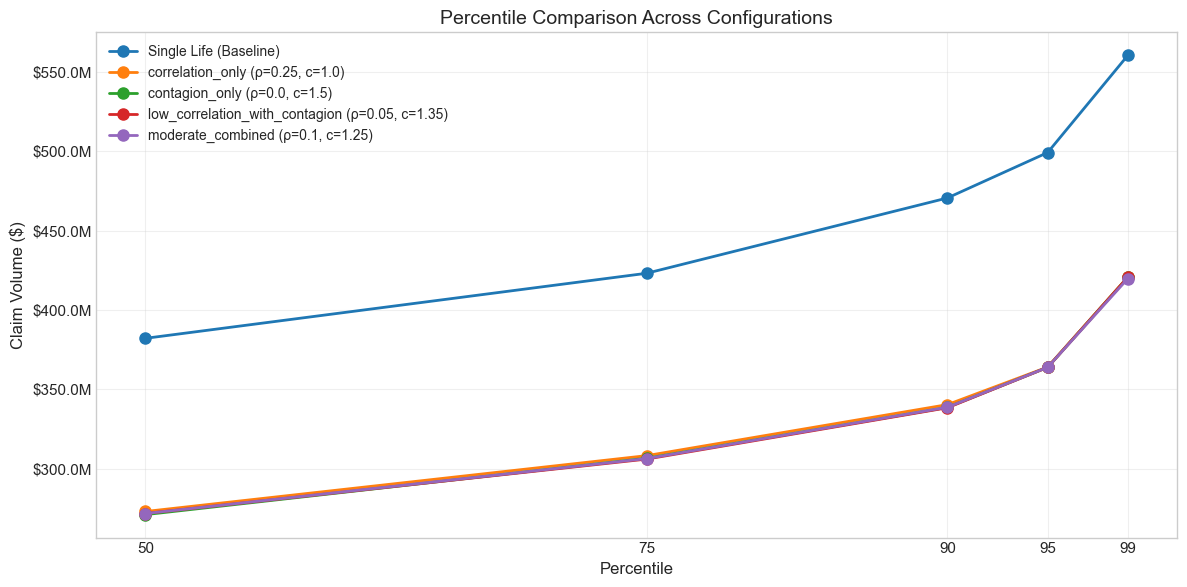

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

percentiles = [50, 75, 90, 95, 99]

# Calculate percentiles for baseline
baseline_pcts = [np.percentile(baseline_results['claim_volume_baseline'], p) for p in percentiles]
ax.plot(percentiles, baseline_pcts, 'o-', linewidth=2, markersize=8, 
        label='Single Life (Baseline)', color=colors[0])

# Calculate percentiles for each configuration
for i, config_name in enumerate(configs_to_test):
    results = joint_results[config_name]
    params = get_joint_life_params(config_name)
    pcts = [np.percentile(results['claim_volume_baseline'], p) for p in percentiles]
    ax.plot(percentiles, pcts, 'o-', linewidth=2, markersize=8,
            label=f'{config_name} (ρ={params["rho"]}, c={params["contagion_multiplier"]})', 
            color=colors[i + 1])

ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Claim Volume ($)', fontsize=12)
ax.set_title('Percentile Comparison Across Configurations', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.set_xticks(percentiles)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Sensitivity: Impact of rho vs Contagion

Exploring how different values of ρ and contagion affect results.

In [15]:
# Test a range of rho values with no contagion
rho_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
rho_results = []

for rho in rho_values:
    np.random.seed(RANDOM_SEED)
    
    results = stochastic_runs_portfolio(
        data=portfolio,
        n_trials=N_TRIALS,
        volume_col='volume',
        baseline_qx_col='baseline_qx',
        shocked_qx_col='shocked_qx',
        life_status_col='life_status',
        policy_col='policy_number',
        life_id_col='life_id',
        rho=rho,
        contagion_multiplier=1.0,  # No contagion
        n_processes=1,
    )
    
    rho_results.append({
        'rho': rho,
        'mean_volume': np.mean(results['claim_volume_baseline']),
        'joint_claims': np.mean(results['joint_life_claim_count_baseline']),
    })

rho_df = pd.DataFrame(rho_results)

In [16]:
# Test a range of contagion values with no correlation
contagion_values = [1.0, 1.25, 1.5, 1.75, 2.0]
contagion_results = []

for contagion in contagion_values:
    np.random.seed(RANDOM_SEED)
    
    results = stochastic_runs_portfolio(
        data=portfolio,
        n_trials=N_TRIALS,
        volume_col='volume',
        baseline_qx_col='baseline_qx',
        shocked_qx_col='shocked_qx',
        life_status_col='life_status',
        policy_col='policy_number',
        life_id_col='life_id',
        rho=0.0,  # No correlation
        contagion_multiplier=contagion,
        n_processes=1,
    )
    
    contagion_results.append({
        'contagion': contagion,
        'mean_volume': np.mean(results['claim_volume_baseline']),
        'joint_claims': np.mean(results['joint_life_claim_count_baseline']),
    })

contagion_df = pd.DataFrame(contagion_results)

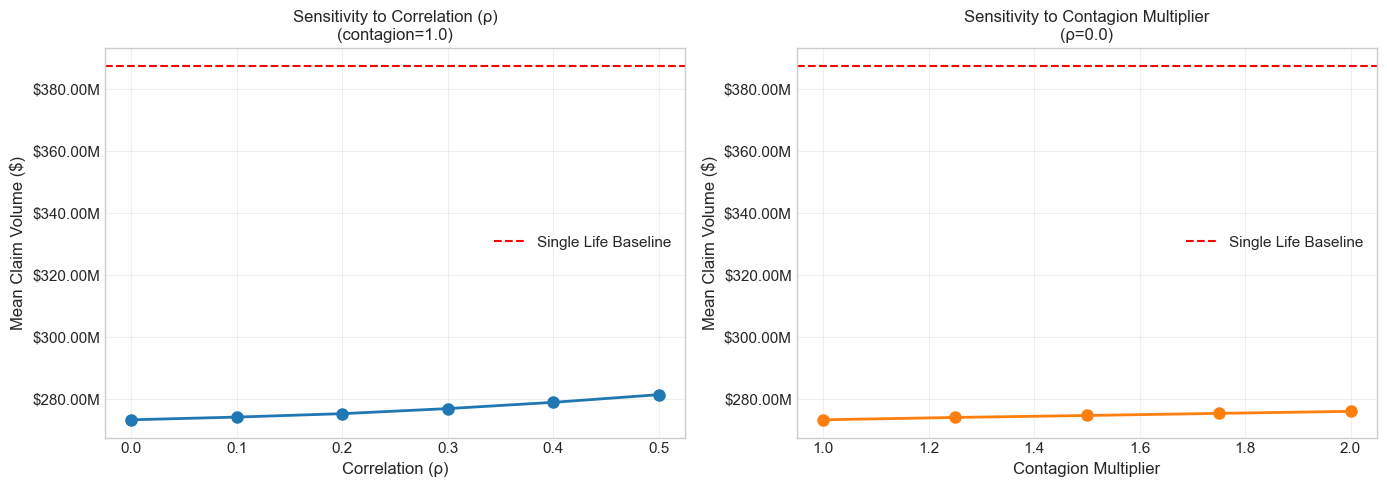

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot rho sensitivity
ax1.plot(rho_df['rho'], rho_df['mean_volume'], 'o-', linewidth=2, markersize=8, color=colors[0])
ax1.axhline(y=baseline_mean, color='red', linestyle='--', label=f'Single Life Baseline')
ax1.set_xlabel('Correlation (ρ)', fontsize=12)
ax1.set_ylabel('Mean Claim Volume ($)', fontsize=12)
ax1.set_title('Sensitivity to Correlation (ρ)\n(contagion=1.0)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.2f}M'))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot contagion sensitivity
ax2.plot(contagion_df['contagion'], contagion_df['mean_volume'], 'o-', linewidth=2, markersize=8, color=colors[1])
ax2.axhline(y=baseline_mean, color='red', linestyle='--', label=f'Single Life Baseline')
ax2.set_xlabel('Contagion Multiplier', fontsize=12)
ax2.set_ylabel('Mean Claim Volume ($)', fontsize=12)
ax2.set_title('Sensitivity to Contagion Multiplier\n(ρ=0.0)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.2f}M'))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Key Findings

### Summary

In [18]:
print("=" * 70)
print("KEY FINDINGS")
print("=" * 70)

print(f"\nPortfolio: {TOTAL_LIVES:,} lives ({JOINT_LIFE_FRACTION*100:.0f}% joint life)")
print(f"Simulation: {N_TRIALS:,} trials\n")

print("1. JOINT LIFE REDUCES TOTAL CLAIMS")
print("   Last-to-die logic means claims only trigger when BOTH lives die.")
print(f"   Single life baseline mean: ${baseline_mean:,.0f}")
print(f"   Best joint life config mean: ${min([np.mean(joint_results[c]['claim_volume_baseline']) for c in configs_to_test]):,.0f}")

print("\n2. CORRELATION (ρ) VS CONTAGION TRADE-OFF")
print("   Both parameters increase joint death probability.")
print("   In single-period models, they have similar effects:")
print(f"   - ρ=0.30 with contagion=1.0 gives similar results to")
print(f"   - ρ=0.00 with contagion=1.5")

print("\n3. RECOMMENDED CONFIGURATIONS")
print("   For single-period annual models:")
print("   - Use 'correlation_only' (simpler, single parameter to calibrate)")
print("   For multi-period projections:")
print("   - Use 'multi_period_literature' (both effects, literature-based)")

print("\n" + "=" * 70)

KEY FINDINGS

Portfolio: 10,000 lives (20% joint life)
Simulation: 1,000 trials

1. JOINT LIFE REDUCES TOTAL CLAIMS
   Last-to-die logic means claims only trigger when BOTH lives die.
   Single life baseline mean: $387,530,372
   Best joint life config mean: $274,717,506

2. CORRELATION (ρ) VS CONTAGION TRADE-OFF
   Both parameters increase joint death probability.
   In single-period models, they have similar effects:
   - ρ=0.30 with contagion=1.0 gives similar results to
   - ρ=0.00 with contagion=1.5

3. RECOMMENDED CONFIGURATIONS
   For single-period annual models:
   - Use 'correlation_only' (simpler, single parameter to calibrate)
   For multi-period projections:
   - Use 'multi_period_literature' (both effects, literature-based)

